# RQ5: Leakage-Controlled Retrieval-Based Proxy Policy Matching

**RQ5:** Can retrieval-based clause matching provide a reliable proxy for policy-aware comparison against standard clause repositories?

This fixed journal version prevents self-retrieval leakage by:

1. Building the reference repository only from **training contracts**.
2. Using query clauses only from **held-out test contracts**.
3. Excluding exact duplicate texts between query and repository.
4. Reporting Recall@k and MRR for BM25 and SBERT retrieval.
5. Saving journal-ready CSV tables and figures.

Expected local folder structure:

```text
C:\Users\a2510\Desktop\new_code\
├── cuad\
├── lex_glue\
├── all-MiniLM-L6-v2\
└── RQ5_retrieval_policy_matching_LEAKAGE_CONTROLLED.ipynb
```

In [1]:
# ============================================================
# Setup
# ============================================================

from pathlib import Path
import os, re, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics.pairwise import cosine_similarity

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None

try:
    from rank_bm25 import BM25Okapi
except Exception:
    BM25Okapi = None

try:
    from datasets import load_from_disk
except Exception:
    load_from_disk = None

BASE_DIR = Path.cwd()
CUAD_DIR = BASE_DIR / "cuad"
LEX_DIR = BASE_DIR / "lex_glue"
MODEL_DIR = BASE_DIR / "all-MiniLM-L6-v2"

OUTPUT_DIR = BASE_DIR / "outputs_journal_v3"
CSV_DIR = OUTPUT_DIR / "csv"
FIG_DIR = OUTPUT_DIR / "figures"
CSV_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("BASE_DIR:", BASE_DIR)
print("CUDA device:", DEVICE)
print("CUAD exists:", CUAD_DIR.exists(), CUAD_DIR)
print("LexGLUE exists:", LEX_DIR.exists(), LEX_DIR)
print("SBERT model exists:", MODEL_DIR.exists(), MODEL_DIR)
if DEVICE == "cuda":
    try:
        print("GPU:", torch.cuda.get_device_name(0))
    except Exception:
        pass

BASE_DIR: c:\Users\a2510\Desktop\new_code
CUDA device: cuda
CUAD exists: True c:\Users\a2510\Desktop\new_code\cuad
LexGLUE exists: True c:\Users\a2510\Desktop\new_code\lex_glue
SBERT model exists: True c:\Users\a2510\Desktop\new_code\all-MiniLM-L6-v2
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ============================================================
# Loader utilities
# ============================================================

def clean_text(x):
    if x is None:
        return ""
    if isinstance(x, float) and pd.isna(x):
        return ""
    x = str(x)
    x = x.replace("\x00", " ")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def normalize_for_duplicate_check(x):
    x = clean_text(x).lower()
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def normalize_label(label):
    label = clean_text(label)
    m = re.search(r'"([^"]+)"', label)
    if m:
        return clean_text(m.group(1))
    label = re.sub(r"(?i)^highlight the parts.*?related to", "", label)
    label = re.sub(r"(?i)that should be reviewed by a lawyer.*$", "", label)
    label = label.strip(" .:-")
    return label if label else "Unknown"

def savecsv(df, filename):
    path = CSV_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("Saved CSV:", path)
    return path

def savefig(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
    return path

def find_files(root, suffixes):
    root = Path(root)
    files = []
    if not root.exists():
        return files
    for suf in suffixes:
        files += list(root.rglob(f"*{suf}"))
    return files

def pick_column(cols, candidates):
    cols = list(cols)
    lower = {str(c).lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    for c in cols:
        lc = str(c).lower()
        if any(cand.lower() in lc for cand in candidates):
            return c
    return None

def dataframe_from_hf_dataset(ds):
    frames = []
    if hasattr(ds, "keys") and not isinstance(ds, list):
        for split in ds.keys():
            try:
                frames.append(ds[split].to_pandas())
            except Exception:
                pass
    else:
        try:
            frames.append(ds.to_pandas())
        except Exception:
            pass
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_cuad_samples(cuad_dir=CUAD_DIR, min_len=20):
    """
    Loads real local CUAD data.
    Supports:
    - HuggingFace load_from_disk folders
    - CSV/XLSX
    - SQuAD-style JSON
    Output columns:
    contract_id, text, raw_label, label
    """
    cuad_dir = Path(cuad_dir)
    rows = []

    # HuggingFace Arrow/load_from_disk format
    if load_from_disk is not None and (cuad_dir / "dataset_info.json").exists():
        try:
            ds = load_from_disk(str(cuad_dir))
            hdf = dataframe_from_hf_dataset(ds)
            if len(hdf) > 0:
                text_col = pick_column(hdf.columns, ["answers", "answer", "text", "context", "clause", "clause_text"])
                label_col = pick_column(hdf.columns, ["question", "label", "category", "clause_category"])
                contract_col = pick_column(hdf.columns, ["title", "contract", "contract_id", "document", "filename"])

                parsed = []
                for _, r in hdf.iterrows():
                    contract_id = clean_text(r[contract_col]) if contract_col else "hf_contract"
                    raw_label = clean_text(r[label_col]) if label_col else "Unknown"
                    label = normalize_label(raw_label)
                    val = r[text_col] if text_col else ""

                    if isinstance(val, dict) and "text" in val:
                        texts = val["text"]
                        if not isinstance(texts, list):
                            texts = [texts]
                    elif isinstance(val, list):
                        texts = val
                    else:
                        texts = [val]

                    if not texts or all(len(clean_text(t)) < min_len for t in texts):
                        if "context" in hdf.columns:
                            texts = [r["context"]]

                    for t in texts:
                        t = clean_text(t)
                        if len(t) >= min_len:
                            parsed.append({"contract_id": contract_id, "text": t, "raw_label": raw_label, "label": label})
                if parsed:
                    rows.append(pd.DataFrame(parsed))
        except Exception as e:
            print("HF CUAD loading failed; trying files:", e)

    # Tabular files
    for fp in find_files(cuad_dir, [".csv", ".xlsx", ".xls"]):
        try:
            df = pd.read_csv(fp) if fp.suffix.lower() == ".csv" else pd.read_excel(fp)
        except Exception:
            continue
        text_col = pick_column(df.columns, ["answer", "answers", "clause", "clause_text", "text", "context", "excerpt", "span"])
        label_col = pick_column(df.columns, ["category", "clause_category", "label", "question", "clause type", "clause_type"])
        contract_col = pick_column(df.columns, ["contract", "contract_id", "document", "document_id", "file", "filename", "title"])
        if text_col and label_col:
            tmp = pd.DataFrame()
            tmp["text"] = df[text_col].apply(clean_text)
            tmp["raw_label"] = df[label_col].apply(clean_text)
            tmp["label"] = tmp["raw_label"].apply(normalize_label)
            tmp["contract_id"] = df[contract_col].astype(str) if contract_col else fp.stem
            tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
            if len(tmp):
                rows.append(tmp[["contract_id", "text", "raw_label", "label"]])

    # SQuAD-style JSON
    for fp in find_files(cuad_dir, [".json"]):
        try:
            obj = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            try:
                obj = json.loads(fp.read_text(encoding="latin-1"))
            except Exception:
                continue
        if not isinstance(obj, dict) or "data" not in obj:
            continue

        parsed = []
        for doc in obj.get("data", []):
            contract_id = clean_text(doc.get("title", fp.stem))
            for para in doc.get("paragraphs", []):
                for qa in para.get("qas", []):
                    raw_label = clean_text(qa.get("question", qa.get("id", "Unknown")))
                    label = normalize_label(raw_label)
                    for ans in qa.get("answers", []):
                        t = clean_text(ans.get("text", ""))
                        if len(t) >= min_len:
                            parsed.append({"contract_id": contract_id, "text": t, "raw_label": raw_label, "label": label})
        if parsed:
            rows.append(pd.DataFrame(parsed))

    if not rows:
        raise FileNotFoundError(f"No usable CUAD samples found in {cuad_dir}.")

    data = pd.concat(rows, ignore_index=True).drop_duplicates()
    data = data[(data["text"].str.len() >= min_len) & (data["label"].str.len() > 0)]
    data = data.reset_index(drop=True)
    data["text_norm"] = data["text"].apply(normalize_for_duplicate_check)

    print("Loaded CUAD samples:", data.shape)
    print("Unique contracts:", data["contract_id"].nunique())
    print("Unique labels:", data["label"].nunique())
    print(data["label"].value_counts().head(10))
    return data

def load_lexglue_samples(lex_dir=LEX_DIR, subset_keywords=("ledgar",), min_len=10):
    """
    Optional supplementary loading. If unavailable, RQ5 still runs on CUAD-only.
    Output columns: source, subset, contract_id, text, label, text_norm
    """
    lex_dir = Path(lex_dir)
    rows = []

    # HF folders
    if load_from_disk is not None:
        candidates = [p for p in lex_dir.rglob("*") if p.is_dir() and (p / "dataset_info.json").exists()]
        for p in candidates:
            low = str(p).lower()
            if not any(k.lower() in low for k in subset_keywords):
                continue
            try:
                ds = load_from_disk(str(p))
                df = dataframe_from_hf_dataset(ds)
                if len(df) == 0:
                    continue
                text_col = pick_column(df.columns, ["text", "sentence", "paragraph", "provision", "clause", "context"])
                label_col = pick_column(df.columns, ["label", "labels", "category", "answer", "class"])
                if text_col and label_col:
                    tmp = pd.DataFrame({
                        "source": "LexGLUE",
                        "subset": p.name,
                        "contract_id": "lexglue_" + p.name,
                        "text": df[text_col].apply(clean_text),
                        "label": df[label_col].astype(str).apply(clean_text)
                    })
                    tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
                    rows.append(tmp)
            except Exception:
                pass

    # File-based
    for fp in find_files(lex_dir, [".csv", ".jsonl", ".json"]):
        low = str(fp).lower()
        if not any(k.lower() in low for k in subset_keywords):
            continue
        try:
            if fp.suffix.lower() == ".csv":
                df = pd.read_csv(fp)
            elif fp.suffix.lower() == ".jsonl":
                df = pd.read_json(fp, lines=True)
            else:
                obj = json.loads(fp.read_text(encoding="utf-8"))
                if isinstance(obj, list):
                    df = pd.DataFrame(obj)
                elif isinstance(obj, dict) and "data" in obj and isinstance(obj["data"], list):
                    df = pd.DataFrame(obj["data"])
                else:
                    continue
        except Exception:
            continue

        text_col = pick_column(df.columns, ["text", "sentence", "paragraph", "provision", "clause", "context"])
        label_col = pick_column(df.columns, ["label", "labels", "category", "answer", "class"])
        if text_col and label_col:
            tmp = pd.DataFrame({
                "source": "LexGLUE",
                "subset": fp.parent.name,
                "contract_id": "lexglue_" + fp.parent.name,
                "text": df[text_col].apply(clean_text),
                "label": df[label_col].astype(str).apply(clean_text)
            })
            tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
            rows.append(tmp)

    if not rows:
        print("No LexGLUE LEDGAR repository loaded. Continuing with CUAD-only repository.")
        return pd.DataFrame(columns=["source", "subset", "contract_id", "text", "label", "text_norm"])

    data = pd.concat(rows, ignore_index=True).drop_duplicates().reset_index(drop=True)
    data["text_norm"] = data["text"].apply(normalize_for_duplicate_check)
    print("Loaded LexGLUE samples:", data.shape)
    print(data["subset"].value_counts().head())
    return data

def get_sbert_model():
    if SentenceTransformer is None:
        raise ImportError("sentence-transformers is missing. Run: pip install sentence-transformers")
    if not MODEL_DIR.exists():
        raise FileNotFoundError(f"Local SBERT model folder not found: {MODEL_DIR}")
    return SentenceTransformer(str(MODEL_DIR), device=DEVICE)

## 1. Load real CUAD and create leakage-controlled train/test contracts

In [3]:
cuad = load_cuad_samples()

# Keep clause categories with enough examples for meaningful retrieval evaluation.
vc = cuad["label"].value_counts()
valid_labels = vc[vc >= 8].index
cuad = cuad[cuad["label"].isin(valid_labels)].reset_index(drop=True)

# Contract-level split prevents same-contract leakage.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(cuad, groups=cuad["contract_id"]))

train_cuad = cuad.iloc[train_idx].reset_index(drop=True)
test_cuad = cuad.iloc[test_idx].reset_index(drop=True)

print("Train CUAD:", train_cuad.shape, "contracts:", train_cuad["contract_id"].nunique())
print("Test CUAD:", test_cuad.shape, "contracts:", test_cuad["contract_id"].nunique())
print("Train/Test contract overlap:", len(set(train_cuad["contract_id"]) & set(test_cuad["contract_id"])))

savecsv(train_cuad[["contract_id", "label", "text"]].head(500), "rq5_fixed_train_repository_preview.csv")
savecsv(test_cuad[["contract_id", "label", "text"]].head(500), "rq5_fixed_test_queries_preview.csv")

Loaded CUAD samples: (11734, 5)
Unique contracts: 510
Unique labels: 41
label
Parties                      1121
License Grant                 774
Cap On Liability              672
Anti-Assignment               651
Audit Rights                  642
Insurance                     558
Expiration Date               464
Governing Law                 462
Post-Termination Services     449
Document Name                 441
Name: count, dtype: int64
Train CUAD: (9343, 5) contracts: 408
Test CUAD: (2391, 5) contracts: 102
Train/Test contract overlap: 0
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\csv\rq5_fixed_train_repository_preview.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\csv\rq5_fixed_test_queries_preview.csv


WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v3/csv/rq5_fixed_test_queries_preview.csv')

## 2. Build reference repository from train contracts only

In [4]:
# Main repository: CUAD train clauses only.
repo = train_cuad[["contract_id", "text", "text_norm", "label"]].drop_duplicates().copy()
repo["source"] = "CUAD_train_contracts"
repo["subset"] = "cuad_train"

# Optional supplementary reference examples from LexGLUE LEDGAR.
# These are used only as additional reference clauses, not as test queries.
try:
    lex = load_lexglue_samples(subset_keywords=("ledgar",))
    if len(lex) > 0:
        # Keep LexGLUE as supplementary repository.
        lex_repo = lex[["contract_id", "text", "text_norm", "label", "source", "subset"]].drop_duplicates()
        repo = pd.concat([repo, lex_repo], ignore_index=True)
except Exception as e:
    print("LexGLUE loading failed, using CUAD train repository only:", e)

repo = repo[repo["text"].str.len() >= 20].drop_duplicates("text_norm").reset_index(drop=True)

# Query set: CUAD test clauses only.
query_df = test_cuad[["contract_id", "text", "text_norm", "label"]].drop_duplicates().reset_index(drop=True)

# Query labels must exist in CUAD train repository to make label-consistency evaluation possible.
train_labels = set(train_cuad["label"])
query_df = query_df[query_df["label"].isin(train_labels)].reset_index(drop=True)

# Optional speed cap for very large local datasets. Increase/remove if desired.
MAX_QUERIES = 800
if len(query_df) > MAX_QUERIES:
    query_df = query_df.sample(MAX_QUERIES, random_state=RANDOM_STATE).reset_index(drop=True)

print("Reference repository size:", repo.shape)
print("Query set size:", query_df.shape)
print("Exact duplicate text overlap before per-query filtering:", len(set(repo["text_norm"]) & set(query_df["text_norm"])))

savecsv(repo.head(1000), "rq5_fixed_reference_repository_leakage_controlled.csv")
savecsv(query_df.head(1000), "rq5_fixed_query_set_heldout_contracts.csv")

No LexGLUE LEDGAR repository loaded. Continuing with CUAD-only repository.
Reference repository size: (8058, 6)
Query set size: (800, 4)
Exact duplicate text overlap before per-query filtering: 45
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\csv\rq5_fixed_reference_repository_leakage_controlled.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\csv\rq5_fixed_query_set_heldout_contracts.csv


WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v3/csv/rq5_fixed_query_set_heldout_contracts.csv')

## 3. Leakage-controlled BM25 and SBERT retrieval

In [5]:
if BM25Okapi is None:
    raise ImportError("rank-bm25 missing. Run: pip install rank-bm25")

sbert_model = get_sbert_model()

# BM25 index over full leakage-controlled train repository.
tokenized_repo = [t.lower().split() for t in repo["text"]]
bm25 = BM25Okapi(tokenized_repo)

# SBERT embeddings for train repository and held-out queries.
repo_emb = sbert_model.encode(
    repo["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

query_emb = sbert_model.encode(
    query_df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Ks = [1, 3, 5, 10]
rows = []
qualitative = []

for i, q in query_df.iterrows():
    q_text = q["text"]
    q_norm = q["text_norm"]
    q_label = q["label"]
    q_contract = q["contract_id"]

    # Per-query leakage mask:
    # 1. exclude exact same normalized text
    # 2. exclude same contract if somehow present
    valid_mask = (repo["text_norm"].values != q_norm) & (repo["contract_id"].astype(str).values != str(q_contract))
    valid_indices = np.where(valid_mask)[0]

    if len(valid_indices) == 0:
        continue

    # BM25 scores, then restrict to valid indices
    bm_scores_all = np.asarray(bm25.get_scores(q_text.lower().split()))
    bm_valid_scores = bm_scores_all[valid_indices]
    bm_order = valid_indices[np.argsort(bm_valid_scores)[::-1]]

    # SBERT cosine, then restrict
    sim_all = repo_emb @ query_emb[i]
    sim_valid = sim_all[valid_indices]
    sb_order = valid_indices[np.argsort(sim_valid)[::-1]]

    for method, order, score_array in [
        ("BM25_leakage_controlled", bm_order, bm_scores_all),
        ("SBERT_leakage_controlled", sb_order, sim_all),
    ]:
        max_k = max(Ks)
        top_indices = order[:max_k]
        top_labels = repo.iloc[top_indices]["label"].tolist()
        top_scores = [float(score_array[idx]) for idx in top_indices]

        for K in Ks:
            labels_k = top_labels[:K]
            hit = int(q_label in labels_k)
            rr = 0.0
            for rank, lab in enumerate(labels_k, start=1):
                if lab == q_label:
                    rr = 1.0 / rank
                    break

            rows.append({
                "query_id": i,
                "query_contract_id": q_contract,
                "true_label": q_label,
                "method": method,
                "k": K,
                "hit_at_k": hit,
                "rr": rr,
                "top1_label": top_labels[0] if top_labels else None,
                "top1_score": top_scores[0] if top_scores else None,
                "exact_duplicate_excluded": True,
                "same_contract_excluded": True
            })

        if i < 60:
            qualitative.append({
                "query_id": i,
                "query_contract_id": q_contract,
                "query_label": q_label,
                "query_text": q_text[:700],
                "method": method,
                "top1_label": top_labels[0] if top_labels else None,
                "top1_score": top_scores[0] if top_scores else None,
                "top1_text": repo.iloc[top_indices[0]]["text"][:700] if len(top_indices) else None,
                "top1_contract_id": repo.iloc[top_indices[0]]["contract_id"] if len(top_indices) else None,
                "top1_source": repo.iloc[top_indices[0]]["source"] if len(top_indices) else None,
            })

retrieval_df = pd.DataFrame(rows)
qualitative_df = pd.DataFrame(qualitative)

summary_df = retrieval_df.groupby(["method", "k"]).agg(
    recall_at_k=("hit_at_k", "mean"),
    mrr=("rr", "mean"),
    avg_top1_score=("top1_score", "mean"),
    n_queries=("query_id", "nunique")
).reset_index()

display(summary_df)

savecsv(retrieval_df, "rq5_fixed_retrieval_results_all_k_leakage_controlled.csv")
savecsv(summary_df, "rq5_fixed_retrieval_summary_journal_leakage_controlled.csv")
savecsv(qualitative_df, "rq5_fixed_qualitative_retrieval_examples_leakage_controlled.csv")

Batches: 100%|██████████| 13/13 [00:00<00:00, 31.89it/s]


,method,k,recall_at_k,mrr,avg_top1_score,n_queries
0,BM25_leakage_controlled,1,0.61375,0.613750,77.559188,800
1,BM25_leakage_controlled,3,0.74500,0.671458,77.559188,800
2,BM25_leakage_controlled,5,0.80000,0.684271,77.559188,800
3,BM25_leakage_controlled,10,0.86375,0.692993,77.559188,800
4,SBERT_leakage_controlled,1,0.61125,0.611250,0.700406,800
5,SBERT_leakage_controlled,3,0.73750,0.668125,0.700406,800
6,SBERT_leakage_controlled,5,0.78500,0.679063,0.700406,800
7,SBERT_leakage_controlled,10,0.85625,0.688595,0.700406,800


Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\csv\rq5_fixed_retrieval_results_all_k_leakage_controlled.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\csv\rq5_fixed_retrieval_summary_journal_leakage_controlled.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\csv\rq5_fixed_qualitative_retrieval_examples_leakage_controlled.csv


WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v3/csv/rq5_fixed_qualitative_retrieval_examples_leakage_controlled.csv')

## 4. Additional diagnostic: retrieval by clause category

In [6]:
# Category-level recall@5 for diagnosis
cat_df = retrieval_df[retrieval_df["k"] == 5].groupby(["method", "true_label"]).agg(
    recall_at_5=("hit_at_k", "mean"),
    mrr_at_5=("rr", "mean"),
    n=("query_id", "count")
).reset_index().sort_values(["method", "recall_at_5"], ascending=[True, False])

display(cat_df.head(30))
savecsv(cat_df, "rq5_fixed_category_level_retrieval_diagnostics.csv")

,method,true_label,recall_at_5,mrr_at_5,n
13,BM25_leakage_controlled,Governing Law,1.000000,1.000000,31
21,BM25_leakage_controlled,Most Favored Nation,1.000000,1.000000,1
23,BM25_leakage_controlled,No-Solicit Of Employees,1.000000,0.750000,6
30,BM25_leakage_controlled,Price Restrictions,1.000000,0.600000,2
34,BM25_leakage_controlled,Source Code Escrow,1.000000,0.791667,8
35,BM25_leakage_controlled,Termination For Convenience,1.000000,0.777778,12
36,BM25_leakage_controlled,Third Party Beneficiary,1.000000,0.875000,4
9,BM25_leakage_controlled,Document Name,0.967742,0.927419,31
12,BM25_leakage_controlled,Expiration Date,0.964286,0.780357,28
18,BM25_leakage_controlled,License Grant,0.960000,0.873333,50


Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\csv\rq5_fixed_category_level_retrieval_diagnostics.csv


WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v3/csv/rq5_fixed_category_level_retrieval_diagnostics.csv')

## 5. Figures

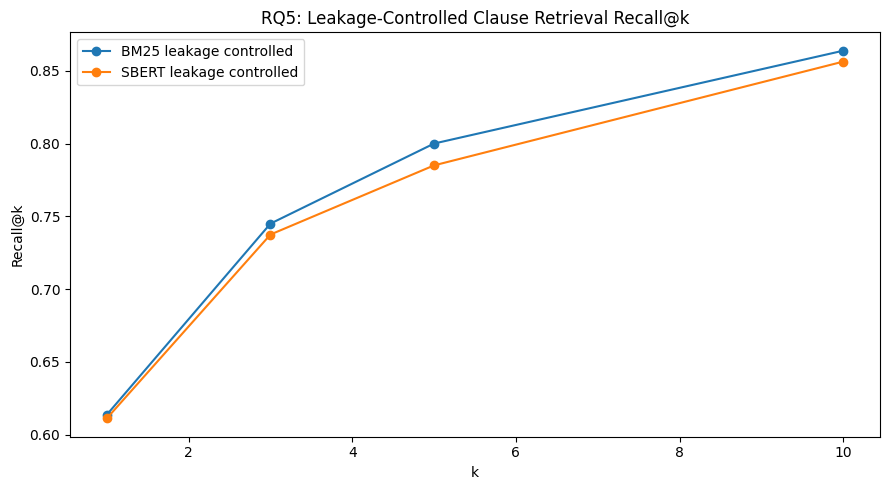

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\figures\rq5_fixed_fig1_leakage_controlled_recall_at_k.png


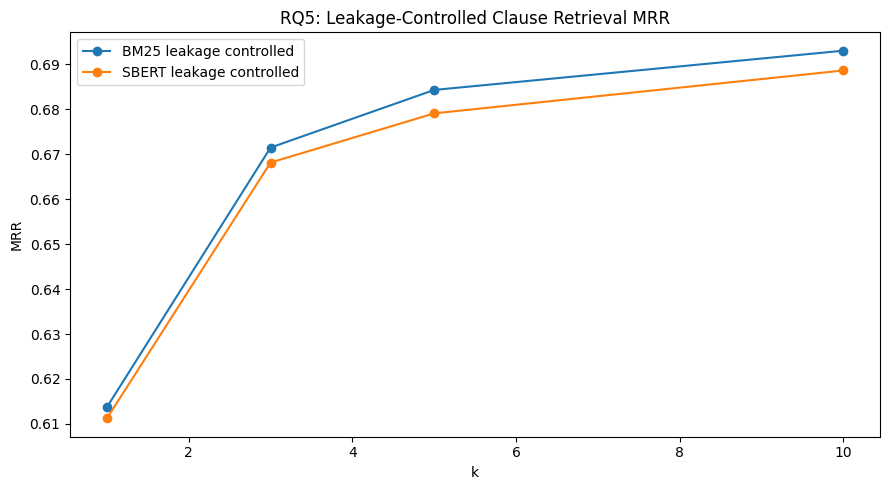

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v3\figures\rq5_fixed_fig2_leakage_controlled_mrr.png


WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v3/figures/rq5_fixed_fig2_leakage_controlled_mrr.png')

In [7]:
# Figure 1: Recall@k curves
plt.figure(figsize=(9, 5))
for method in summary_df["method"].unique():
    g = summary_df[summary_df["method"] == method]
    plt.plot(g["k"], g["recall_at_k"], marker="o", label=method.replace("_", " "))
plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title("RQ5: Leakage-Controlled Clause Retrieval Recall@k")
plt.legend()
savefig("rq5_fixed_fig1_leakage_controlled_recall_at_k.png")

# Figure 2: MRR curves
plt.figure(figsize=(9, 5))
for method in summary_df["method"].unique():
    g = summary_df[summary_df["method"] == method]
    plt.plot(g["k"], g["mrr"], marker="o", label=method.replace("_", " "))
plt.xlabel("k")
plt.ylabel("MRR")
plt.title("RQ5: Leakage-Controlled Clause Retrieval MRR")
plt.legend()
savefig("rq5_fixed_fig2_leakage_controlled_mrr.png")

## 6. Journal interpretation guide

In [8]:
print("""
How to interpret this fixed RQ5:

1. If Recall@5 is still strong after leakage control:
   You can claim that retrieval-based clause matching provides a useful proxy for policy-aware comparison.

2. If scores drop sharply compared with the old RQ5:
   That is normal and academically safer. It means the earlier result had self-retrieval leakage.

3. Safe journal wording:
   'A leakage-controlled retrieval experiment was conducted by constructing the reference repository from training contracts only and using held-out contracts as queries. Exact duplicate texts and same-contract candidates were excluded during retrieval.'

4. Do NOT write:
   'The system performs true organizational policy compliance.'

5. Correct wording:
   'The retrieval module provides a proxy for policy-aware comparison by retrieving label-consistent reference clauses from a standard clause repository.'
""")


How to interpret this fixed RQ5:

1. If Recall@5 is still strong after leakage control:
   You can claim that retrieval-based clause matching provides a useful proxy for policy-aware comparison.

2. If scores drop sharply compared with the old RQ5:
   That is normal and academically safer. It means the earlier result had self-retrieval leakage.

3. Safe journal wording:
   'A leakage-controlled retrieval experiment was conducted by constructing the reference repository from training contracts only and using held-out contracts as queries. Exact duplicate texts and same-contract candidates were excluded during retrieval.'

4. Do NOT write:
   'The system performs true organizational policy compliance.'

5. Correct wording:
   'The retrieval module provides a proxy for policy-aware comparison by retrieving label-consistent reference clauses from a standard clause repository.'

